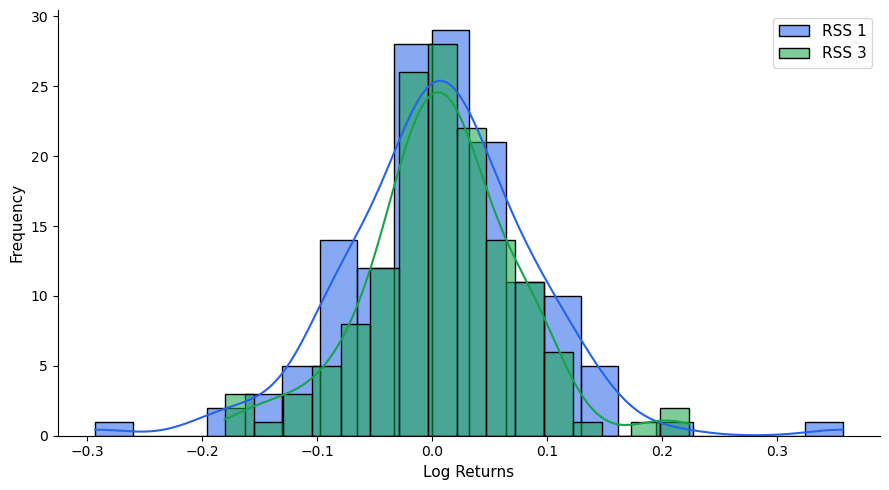

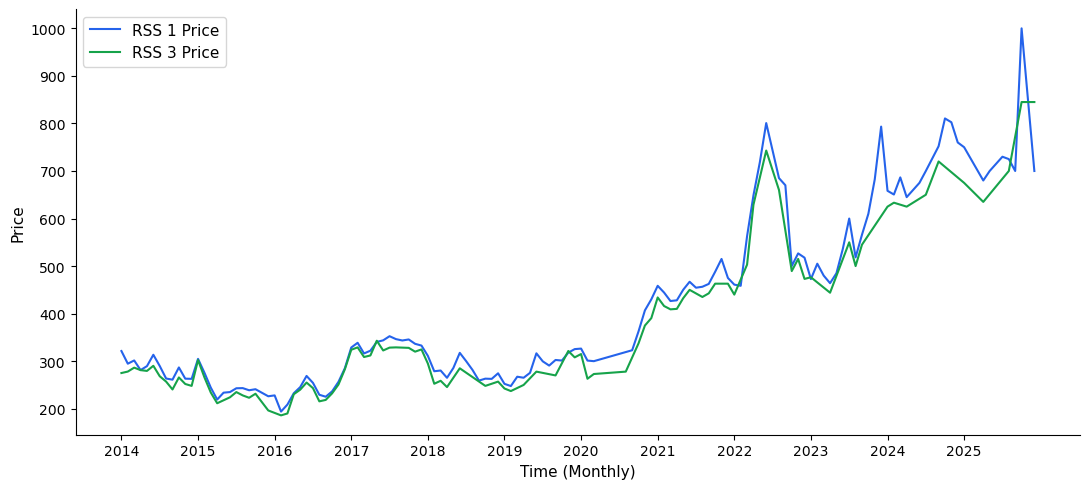

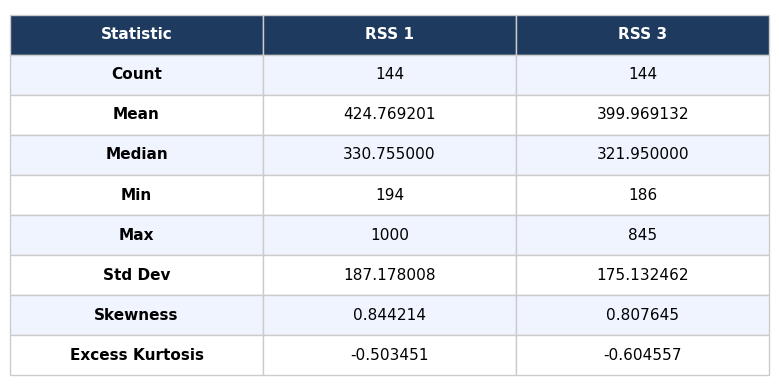

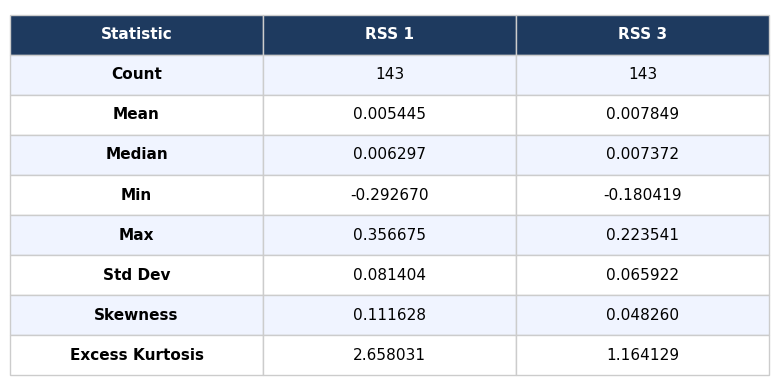

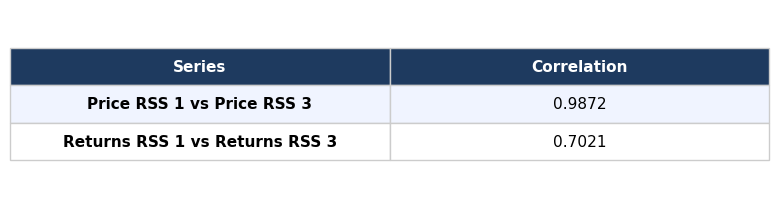

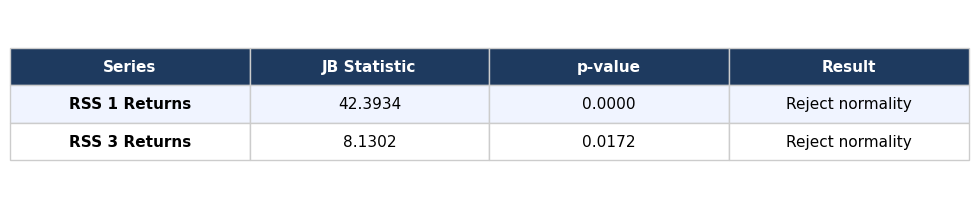

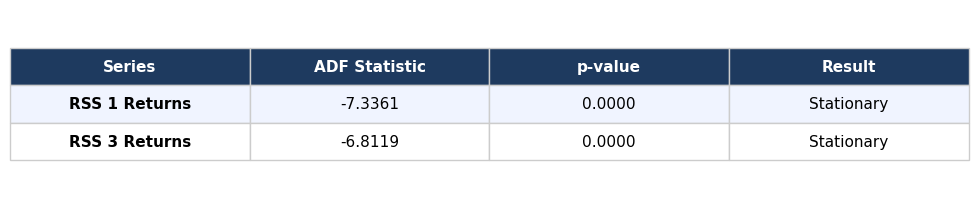

All 7 figures saved as figure_4.1.png to figure_4.7.png!


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import jarque_bera

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 1. Load the data
df = pd.read_csv('Data_Python.csv')

# 2. Calculate Log Returns
df['Returns_RSS1'] = np.log(df['Final_Price_RSS 1'] / df['Final_Price_RSS 1'].shift(1))
df['Returns_RSS3'] = np.log(df['Final_Price_RSS 3'] / df['Final_Price_RSS 3'].shift(1))

# 3. Stats function
def get_stats(series):
    return {
        'Count': series.dropna().count(),
        'Mean': series.mean(),
        'Median': series.median(),
        'Min': series.min(),
        'Max': series.max(),
        'Std Dev': series.std(),
        'Skewness': skew(series.dropna()),
        'Excess Kurtosis': kurtosis(series.dropna(), fisher=True)
    }

HEADER_COLOR = '#1E3A5F'
ROW_COLORS = ['#F0F4FF', '#FFFFFF']

def draw_table(ax, cell_data, cols):
    ax.axis('off')
    table = ax.table(cellText=cell_data, colLabels=cols, cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.3, 2.0)
    for (r, c), cell in table.get_celld().items():
        cell.set_edgecolor('#CCCCCC')
        if r == 0:
            cell.set_facecolor(HEADER_COLOR)
            cell.set_text_props(color='white', fontweight='bold')
        else:
            cell.set_facecolor(ROW_COLORS[(r - 1) % 2])
            if c == 0:
                cell.set_text_props(fontweight='bold')

# ── FIGURE 4.1: Distribution of Log Returns ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['Returns_RSS1'].dropna(), kde=True, color='#2563EB', label='RSS 1', alpha=0.55, ax=ax)
sns.histplot(df['Returns_RSS3'].dropna(), kde=True, color='#16A34A', label='RSS 3', alpha=0.55, ax=ax)
ax.set_xlabel('Log Returns', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figure_4.1.png', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 4.2: Price Levels ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(df.index, df['Final_Price_RSS 1'], label='RSS 1 Price', color='#2563EB', linewidth=1.5)
ax.plot(df.index, df['Final_Price_RSS 3'], label='RSS 3 Price', color='#16A34A', linewidth=1.5)
ax.set_xlabel('Time (Monthly)', fontsize=11)
ax.set_ylabel('Price', fontsize=11)
year_ticks  = [i for i, y in enumerate(df['YEAR']) if 'JAN' in str(y).upper()]
year_labels = [str(y)[:4] for y in df['YEAR'] if 'JAN' in str(y).upper()]
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=0)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figure_4.2.png', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 4.3: Price Stats Table ─────────────────────────────────────────
p1 = get_stats(df['Final_Price_RSS 1'])
p3 = get_stats(df['Final_Price_RSS 3'])
price_df = pd.DataFrame({'RSS 1': p1, 'RSS 3': p3})

def fmt_price(val, row):
    if row == 'Count': return str(int(val))
    if row in ('Min', 'Max'): return f"{val:.0f}"
    return f"{val:.6f}"

rows = price_df.index.tolist()
cell_data = [[row, fmt_price(price_df.loc[row, 'RSS 1'], row),
                   fmt_price(price_df.loc[row, 'RSS 3'], row)] for row in rows]

fig, ax = plt.subplots(figsize=(8, 4))
draw_table(ax, cell_data, ['Statistic', 'RSS 1', 'RSS 3'])
plt.tight_layout()
plt.savefig('figure_4.3.png', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 4.4: Returns Stats Table ───────────────────────────────────────
r1 = get_stats(df['Returns_RSS1'])
r3 = get_stats(df['Returns_RSS3'])
ret_df = pd.DataFrame({'RSS 1': r1, 'RSS 3': r3})

def fmt_ret(val, row):
    if row == 'Count': return str(int(val))
    return f"{val:.6f}"

rows = ret_df.index.tolist()
cell_data = [[row, fmt_ret(ret_df.loc[row, 'RSS 1'], row),
                   fmt_ret(ret_df.loc[row, 'RSS 3'], row)] for row in rows]

fig, ax = plt.subplots(figsize=(8, 4))
draw_table(ax, cell_data, ['Statistic', 'RSS 1', 'RSS 3'])
plt.tight_layout()
plt.savefig('figure_4.4.png', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 4.5: Correlation Table ─────────────────────────────────────────
price_corr   = df['Final_Price_RSS 1'].corr(df['Final_Price_RSS 3'])
returns_corr = df['Returns_RSS1'].corr(df['Returns_RSS3'])

corr_data = [
    ['Price RSS 1 vs Price RSS 3',     f"{price_corr:.4f}"],
    ['Returns RSS 1 vs Returns RSS 3', f"{returns_corr:.4f}"],
]

fig, ax = plt.subplots(figsize=(8, 2.2))
draw_table(ax, corr_data, ['Series', 'Correlation'])
plt.tight_layout()
plt.savefig('figure_4.5.png', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 4.6: Jarque-Bera Table ─────────────────────────────────────────
def jb_row(series, name):
    jb_stat, jb_pvalue, _, _ = jarque_bera(series.dropna())
    result = 'Reject normality' if jb_pvalue < 0.05 else 'Fail to reject normality'
    return [name, f"{jb_stat:.4f}", f"{jb_pvalue:.4f}", result]

jb_data = [
    jb_row(df['Returns_RSS1'], 'RSS 1 Returns'),
    jb_row(df['Returns_RSS3'], 'RSS 3 Returns'),
]

fig, ax = plt.subplots(figsize=(10, 2.2))
draw_table(ax, jb_data, ['Series', 'JB Statistic', 'p-value', 'Result'])
plt.tight_layout()
plt.savefig('figure_4.6.png', dpi=300, bbox_inches='tight')
plt.show()

# ── FIGURE 4.7: ADF Stationarity Table ────────────────────────────────────
def adf_row(series, name):
    result = adfuller(series.dropna())
    conclusion = 'Stationary' if result[1] < 0.05 else 'Non-Stationary'
    return [name, f"{result[0]:.4f}", f"{result[1]:.4f}", conclusion]

adf_data = [
    adf_row(df['Returns_RSS1'], 'RSS 1 Returns'),
    adf_row(df['Returns_RSS3'], 'RSS 3 Returns'),
]

fig, ax = plt.subplots(figsize=(10, 2.2))
draw_table(ax, adf_data, ['Series', 'ADF Statistic', 'p-value', 'Result'])
plt.tight_layout()
plt.savefig('figure_4.7.png', dpi=300, bbox_inches='tight')
plt.show()

print("All 7 figures saved as figure_4.1.png to figure_4.7.png!")